In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [2]:
nav = pd.read_csv("../Data/Processed/02_nav_history_clean.csv")
performance = pd.read_csv("../Data/Processed/07_scheme_performance_clean.csv")

nav["date"] = pd.to_datetime(nav["date"])

In [3]:
nav.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [4]:
nav.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46000 entries, 0 to 45999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   amfi_code  46000 non-null  int64         
 1   date       46000 non-null  datetime64[ns]
 2   nav        46000 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(1)
memory usage: 1.1 MB


In [5]:
nav = nav.sort_values(["amfi_code","date"])

In [6]:
nav["daily_return"] = nav.groupby("amfi_code")["nav"].pct_change()

In [7]:
nav.head(10)

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210
5,100016,2022-01-10,510.7136,-0.008639
6,100016,2022-01-11,513.5542,0.005562
7,100016,2022-01-12,512.3195,-0.002404
8,100016,2022-01-13,510.2445,-0.004050
9,100016,2022-01-14,514.3636,0.008073


In [8]:
nav["daily_return"].isnull().sum()

np.int64(40)

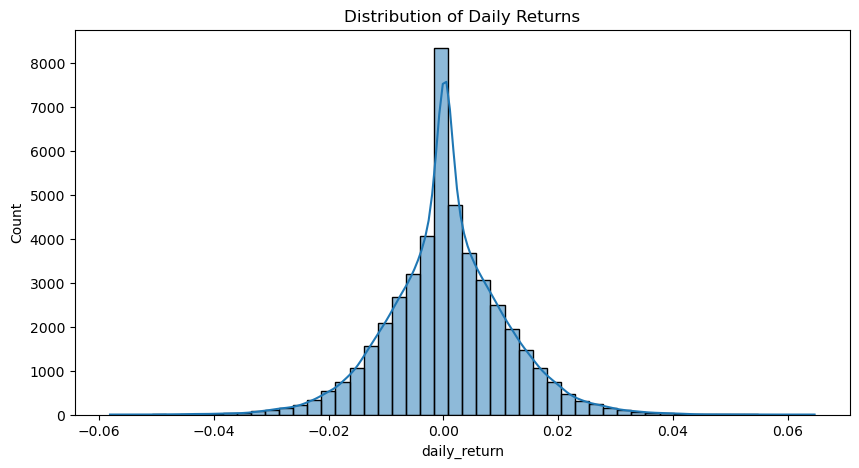

In [9]:
plt.figure(figsize=(10,5))

sns.histplot(
    nav["daily_return"].dropna(),
    bins=50,
    kde=True
)

plt.title("Distribution of Daily Returns")

plt.show()

### Insight 1

Daily returns are concentrated around zero, indicating that most NAV movements are small while extreme gains or losses occur less frequently.

In [10]:
cagr = nav.groupby("amfi_code").agg(
    start_nav=("nav", "first"),
    end_nav=("nav", "last")
).reset_index()

cagr.head()

,amfi_code,start_nav,end_nav
0,100016,520.4608,583.6113
1,100025,26.3169,31.8843
2,100033,107.3758,342.0072
3,101206,305.0996,773.2939
4,101207,38.5736,53.9836


In [11]:
years = 4

In [12]:
cagr["cagr"] = (
    (cagr["end_nav"] / cagr["start_nav"]) ** (1 / years)
) - 1

cagr.head()

,amfi_code,start_nav,end_nav,cagr
0,100016,520.4608,583.6113,0.029044
1,100025,26.3169,31.8843,0.049145
2,100033,107.3758,342.0072,0.335925
3,101206,305.0996,773.2939,0.261757
4,101207,38.5736,53.9836,0.087659


In [13]:
cagr["cagr_pct"] = cagr["cagr"] * 100

cagr.head()

,amfi_code,start_nav,end_nav,cagr,cagr_pct
0,100016,520.4608,583.6113,0.029044,2.904393
1,100025,26.3169,31.8843,0.049145,4.914506
2,100033,107.3758,342.0072,0.335925,33.592541
3,101206,305.0996,773.2939,0.261757,26.175704
4,101207,38.5736,53.9836,0.087659,8.765940


In [14]:
cagr.sort_values("cagr_pct", ascending=False).head(10)

,amfi_code,start_nav,end_nav,cagr,cagr_pct
25,120505,135.8720,473.7640,0.366495,36.649492
21,119598,89.8738,309.2050,0.361925,36.192550
39,149324,81.6814,279.7511,0.360386,36.038601
36,148569,28.8620,97.7435,0.356564,35.656424
34,148567,70.2514,230.2708,0.345538,34.553801
30,120843,49.9131,163.2397,0.344785,34.478486
2,100033,107.3758,342.0072,0.335925,33.592541
38,149323,78.4622,245.3651,0.329805,32.980535
16,119094,68.3023,203.8581,0.314387,31.438672
19,119551,54.3856,149.3216,0.287240,28.724045


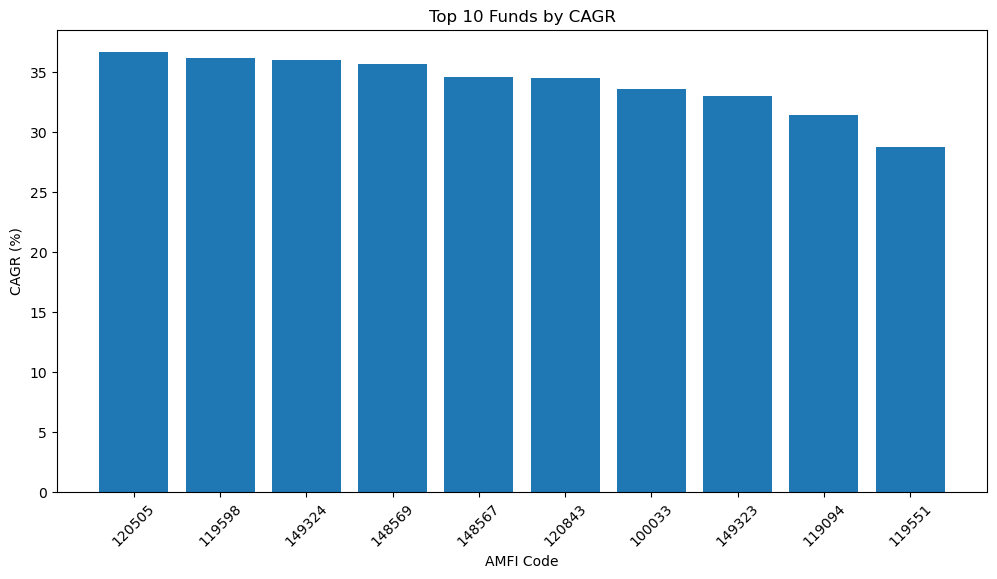

In [15]:
import matplotlib.pyplot as plt

top10 = cagr.sort_values("cagr_pct", ascending=False).head(10)

plt.figure(figsize=(12,6))

plt.bar(
    top10["amfi_code"].astype(str),
    top10["cagr_pct"]
)

plt.title("Top 10 Funds by CAGR")
plt.xlabel("AMFI Code")
plt.ylabel("CAGR (%)")

plt.xticks(rotation=45)

plt.show()

## Insight 2

Funds with higher CAGR delivered stronger annualized growth over the analysis period, indicating better long-term performance.

In [16]:
nav["date"].min(), nav["date"].max()

(Timestamp('2022-01-03 00:00:00'), Timestamp('2026-05-29 00:00:00'))

In [17]:
latest_date = nav["date"].max()

one_year_ago = latest_date - pd.DateOffset(years=1)

print(latest_date)
print(one_year_ago)

2026-05-29 00:00:00
2025-05-29 00:00:00


In [18]:
latest_nav = nav.groupby("amfi_code").last().reset_index()

latest_nav = latest_nav[["amfi_code","nav"]]

latest_nav.rename(columns={"nav":"latest_nav"}, inplace=True)

latest_nav.head()

,amfi_code,latest_nav
0,100016,583.6113
1,100025,31.8843
2,100033,342.0072
3,101206,773.2939
4,101207,53.9836


In [19]:
one_year_nav = (
    nav[nav["date"] >= one_year_ago]
    .groupby("amfi_code")
    .first()
    .reset_index()
)

one_year_nav = one_year_nav[["amfi_code","nav"]]

one_year_nav.rename(columns={"nav":"one_year_nav"}, inplace=True)

one_year_nav.head()

,amfi_code,one_year_nav
0,100016,596.8877
1,100025,30.7452
2,100033,223.1951
3,101206,522.7639
4,101207,71.0180


In [20]:
cagr_1yr = latest_nav.merge(one_year_nav,on="amfi_code")

In [21]:
cagr_1yr["cagr_1yr"] = (
    (cagr_1yr["latest_nav"] / cagr_1yr["one_year_nav"]) - 1
) * 100

cagr_1yr.head()

,amfi_code,latest_nav,one_year_nav,cagr_1yr
0,100016,583.6113,596.8877,-2.224271
1,100025,31.8843,30.7452,3.704969
2,100033,342.0072,223.1951,53.232396
3,101206,773.2939,522.7639,47.924120
4,101207,53.9836,71.0180,-23.986032


In [22]:
cagr_1yr.sort_values("cagr_1yr",ascending=False).head(10)

,amfi_code,latest_nav,one_year_nav,cagr_1yr
21,119598,309.2050,169.1715,82.776059
39,149324,279.7511,169.4037,65.138719
19,119551,149.3216,93.0716,60.437341
2,100033,342.0072,223.1951,53.232396
3,101206,773.2939,522.7639,47.924120
26,120506,404.4207,285.1667,41.819048
36,148569,97.7435,69.9408,39.751761
9,118632,110.5554,82.5157,33.981048
25,120505,473.7640,365.5455,29.604659
32,125497,1204.9571,936.4319,28.675358


In [23]:
cagr_table = performance[["amfi_code", "scheme_name", "fund_house"]].merge(
    cagr_1yr[["amfi_code", "cagr_1yr"]],
    on="amfi_code"
)

cagr_table.head()

,amfi_code,scheme_name,fund_house,cagr_1yr
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,60.437341
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,5.706100
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,82.776059
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,13.947803
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,5.521996


In [24]:
cagr_table.sort_values("cagr_1yr", ascending=False).head(10)

,amfi_code,scheme_name,fund_house,cagr_1yr
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,82.776059
39,149324,DSP Small Cap Fund - Regular - Growth,DSP Mutual Fund,65.138719
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,60.437341
7,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund,53.232396
28,101206,ABSL Frontline Equity Fund - Regular - Growth,Aditya Birla Sun Life MF,47.924120
13,120506,ICICI Pru Value Discovery Fund - Regular - Growth,ICICI Prudential MF,41.819048
36,148569,Mirae Asset Tax Saver Fund - Regular - Growth,Mirae Asset MF,39.751761
15,118632,Nippon India Large Cap Fund - Regular - Growth,Nippon India MF,33.981048
12,120505,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF,29.604659
6,125497,HDFC Top 100 Fund - Direct Plan - Growth,HDFC Mutual Fund,28.675358


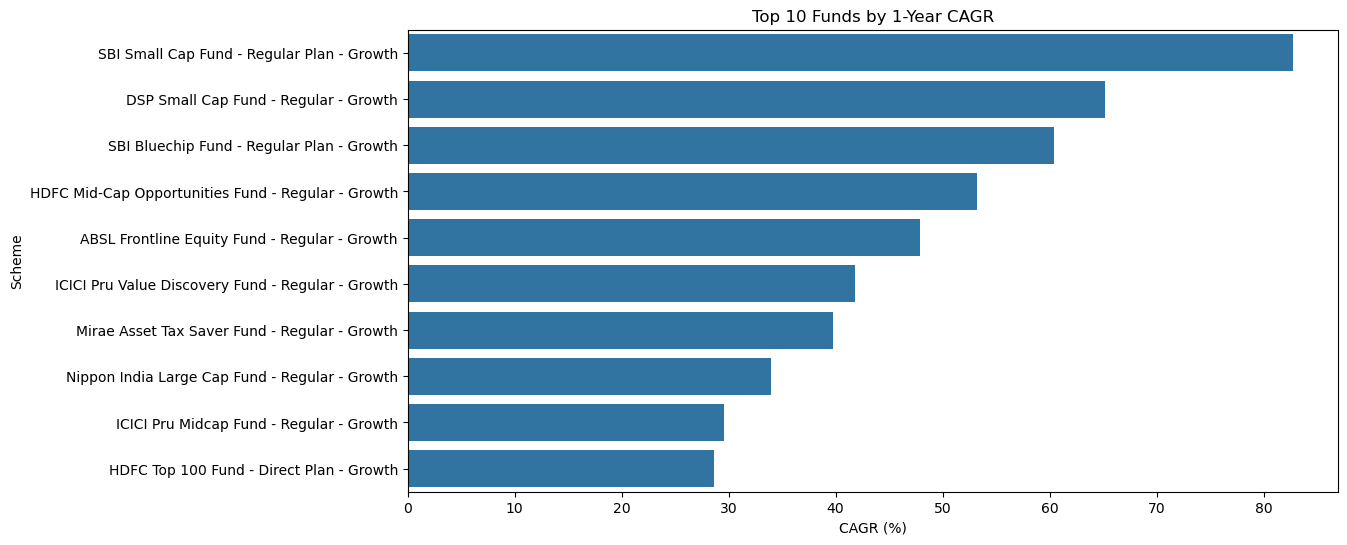

In [25]:
top10 = cagr_table.sort_values("cagr_1yr", ascending=False).head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top10,
    x="cagr_1yr",
    y="scheme_name"
)

plt.title("Top 10 Funds by 1-Year CAGR")
plt.xlabel("CAGR (%)")
plt.ylabel("Scheme")

plt.show()

## Insight 2

The top-performing mutual funds delivered the highest annualized growth over the last one year, indicating strong recent performance.

In [26]:
risk_free_rate = 0.065

sharpe = nav.groupby("amfi_code")["daily_return"].agg(
    mean_return="mean",
    std_return="std"
).reset_index()

sharpe.head()

,amfi_code,mean_return,std_return
0,100016,0.000142,0.009164
1,100025,0.000170,0.002460
2,100033,0.001080,0.011929
3,101206,0.000852,0.009177
4,101207,0.000424,0.016251


In [27]:
import numpy as np

sharpe["sharpe_ratio"] = (
    (sharpe["mean_return"] * 252 - risk_free_rate)
    / (sharpe["std_return"] * np.sqrt(252))
)

sharpe.head()

,amfi_code,mean_return,std_return,sharpe_ratio
0,100016,0.000142,0.009164,-0.201517
1,100025,0.000170,0.002460,-0.567095
2,100033,0.001080,0.011929,1.093699
3,101206,0.000852,0.009177,1.027213
4,101207,0.000424,0.016251,0.162661


In [28]:
sharpe = sharpe.merge(
    performance[["amfi_code", "scheme_name"]],
    on="amfi_code"
)

sharpe.sort_values("sharpe_ratio", ascending=False).head(10)

,amfi_code,mean_return,std_return,sharpe_ratio,scheme_name
34,148567,0.001074,0.008941,1.448291,Mirae Asset Large Cap Fund - Regular - Growth
30,120843,0.001082,0.010008,1.306744,Kotak Flexicap Fund - Regular - Growth
36,148569,0.001124,0.011134,1.234930,Mirae Asset Tax Saver Fund - Regular - Growth
19,119551,0.000917,0.008656,1.208267,SBI Bluechip Fund - Regular Plan - Growth
25,120505,0.001161,0.012152,1.180101,ICICI Pru Midcap Fund - Regular - Growth
38,149323,0.001055,0.011179,1.132122,DSP Midcap Fund - Regular - Growth
2,100033,0.001080,0.011929,1.093699,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
9,118632,0.000865,0.008913,1.081659,Nippon India Large Cap Fund - Regular - Growth
3,101206,0.000852,0.009177,1.027213,ABSL Frontline Equity Fund - Regular - Growth
24,120504,0.000843,0.009048,1.026524,ICICI Pru Bluechip Fund - Direct - Growth


In [29]:
downside = nav.copy()

downside["negative_return"] = downside["daily_return"]

downside.loc[
    downside["negative_return"] > 0,
    "negative_return"
] = np.nan

downside.head()

,amfi_code,date,nav,daily_return,negative_return
0,100016,2022-01-03,520.4608,NaN,NaN
1,100016,2022-01-04,515.0971,-0.010306,-0.010306
2,100016,2022-01-05,521.7239,0.012865,NaN
3,100016,2022-01-06,515.7880,-0.011377,-0.011377
4,100016,2022-01-07,515.1639,-0.001210,-0.001210


In [30]:
downside_std = downside.groupby("amfi_code")["negative_return"].std().reset_index()

downside_std.rename(
    columns={"negative_return":"downside_std"},
    inplace=True
)

downside_std.head()

,amfi_code,downside_std
0,100016,0.005261
1,100025,0.001483
2,100033,0.007133
3,101206,0.005238
4,101207,0.009562


In [31]:
sortino = sharpe.merge(
    downside_std,
    on="amfi_code"
)

sortino.head()

,amfi_code,mean_return,std_return,sharpe_ratio,scheme_name,downside_std
0,100016,0.000142,0.009164,-0.201517,HDFC Top 100 Fund - Regular Plan - Growth,0.005261
1,100025,0.000170,0.002460,-0.567095,HDFC Short Term Debt Fund - Regular - Growth,0.001483
2,100033,0.001080,0.011929,1.093699,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.007133
3,101206,0.000852,0.009177,1.027213,ABSL Frontline Equity Fund - Regular - Growth,0.005238
4,101207,0.000424,0.016251,0.162661,ABSL Small Cap Fund - Regular - Growth,0.009562


In [32]:
sortino["sortino_ratio"] = (
    (sortino["mean_return"] * 252 - risk_free_rate)
    /
    (sortino["downside_std"] * np.sqrt(252))
)

sortino.head()

,amfi_code,mean_return,std_return,sharpe_ratio,scheme_name,downside_std,sortino_ratio
0,100016,0.000142,0.009164,-0.201517,HDFC Top 100 Fund - Regular Plan - Growth,0.005261,-0.351047
1,100025,0.000170,0.002460,-0.567095,HDFC Short Term Debt Fund - Regular - Growth,0.001483,-0.940851
2,100033,0.001080,0.011929,1.093699,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.007133,1.829134
3,101206,0.000852,0.009177,1.027213,ABSL Frontline Equity Fund - Regular - Growth,0.005238,1.799563
4,101207,0.000424,0.016251,0.162661,ABSL Small Cap Fund - Regular - Growth,0.009562,0.276456


In [33]:
sortino = sortino.sort_values(
    "sortino_ratio",
    ascending=False
)

sortino.head(10)

,amfi_code,mean_return,std_return,sharpe_ratio,scheme_name,downside_std,sortino_ratio
34,148567,0.001074,0.008941,1.448291,Mirae Asset Large Cap Fund - Regular - Growth,0.005428,2.385644
30,120843,0.001082,0.010008,1.306744,Kotak Flexicap Fund - Regular - Growth,0.005531,2.364320
36,148569,0.001124,0.011134,1.234930,Mirae Asset Tax Saver Fund - Regular - Growth,0.006404,2.146914
19,119551,0.000917,0.008656,1.208267,SBI Bluechip Fund - Regular Plan - Growth,0.004887,2.140267
25,120505,0.001161,0.012152,1.180101,ICICI Pru Midcap Fund - Regular - Growth,0.007067,2.029353
38,149323,0.001055,0.011179,1.132122,DSP Midcap Fund - Regular - Growth,0.006750,1.875101
9,118632,0.000865,0.008913,1.081659,Nippon India Large Cap Fund - Regular - Growth,0.005211,1.850133
2,100033,0.001080,0.011929,1.093699,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.007133,1.829134
24,120504,0.000843,0.009048,1.026524,ICICI Pru Bluechip Fund - Direct - Growth,0.005145,1.805294
3,101206,0.000852,0.009177,1.027213,ABSL Frontline Equity Fund - Regular - Growth,0.005238,1.799563


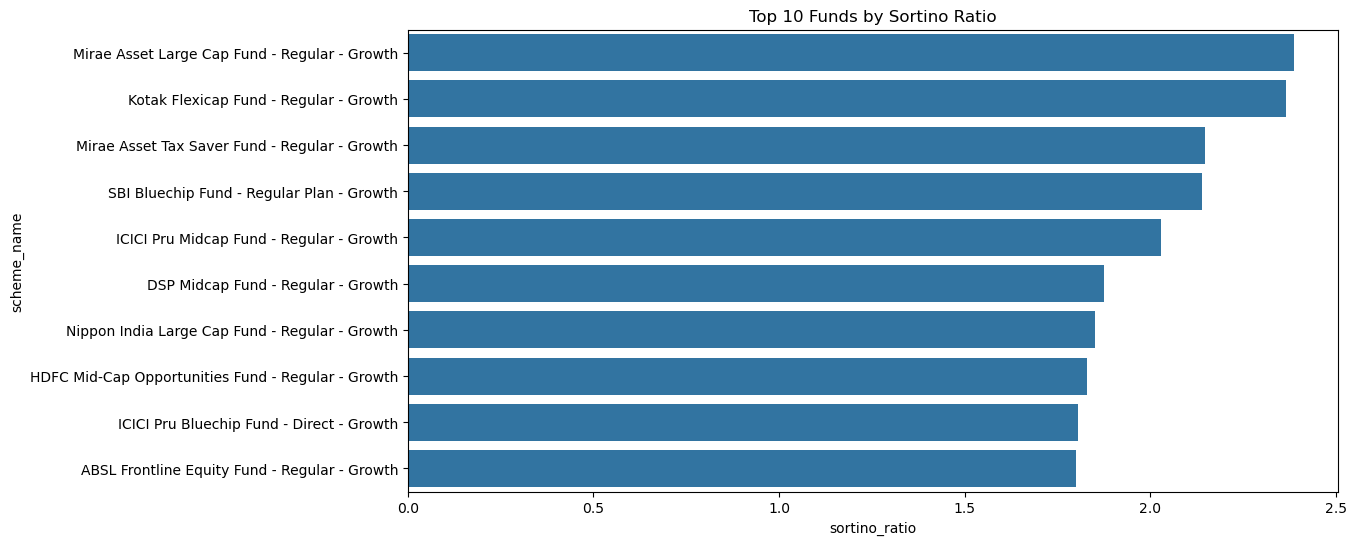

In [34]:
top10 = sortino.head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top10,
    x="sortino_ratio",
    y="scheme_name"
)

plt.title("Top 10 Funds by Sortino Ratio")

plt.show()

## Insight 4

Funds with higher Sortino Ratios generated better risk-adjusted returns while minimizing downside volatility.

In [35]:
benchmark = pd.read_csv("../Data/Raw/10_benchmark_indices.csv")

benchmark.head()

,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


In [36]:
benchmark.columns

Index(['date', 'index_name', 'close_value'], dtype='object')

In [37]:
benchmark.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8050 entries, 0 to 8049
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   date         8050 non-null   object 
 1   index_name   8050 non-null   object 
 2   close_value  8050 non-null   float64
dtypes: float64(1), object(2)
memory usage: 188.8+ KB


In [38]:
benchmark["date"] = pd.to_datetime(benchmark["date"])

In [39]:
benchmark["index_name"].unique()

array(['NIFTY50', 'NIFTY100', 'NIFTY_MIDCAP150', 'BSE_SMALLCAP',
       'NIFTY500', 'CRISIL_LIQUID', 'CRISIL_GILT'], dtype=object)

In [40]:
nifty100 = benchmark[benchmark["index_name"] == "NIFTY100"].copy()

nifty100.head()

,date,index_name,close_value
1150,2022-01-03,NIFTY100,17778.24
1151,2022-01-04,NIFTY100,17537.52
1152,2022-01-05,NIFTY100,17607.73
1153,2022-01-06,NIFTY100,17556.05
1154,2022-01-07,NIFTY100,17664.02


In [41]:
nifty100 = nifty100.sort_values("date")

nifty100["benchmark_return"] = nifty100["close_value"].pct_change()

nifty100.head()

,date,index_name,close_value,benchmark_return
1150,2022-01-03,NIFTY100,17778.24,NaN
1151,2022-01-04,NIFTY100,17537.52,-0.013540
1152,2022-01-05,NIFTY100,17607.73,0.004003
1153,2022-01-06,NIFTY100,17556.05,-0.002935
1154,2022-01-07,NIFTY100,17664.02,0.006150


In [42]:
nifty100 = nifty100[["date", "benchmark_return"]]

nifty100.head()

,date,benchmark_return
1150,2022-01-03,NaN
1151,2022-01-04,-0.013540
1152,2022-01-05,0.004003
1153,2022-01-06,-0.002935
1154,2022-01-07,0.006150


In [43]:
merged = pd.merge(
    nav,
    nifty100,
    on="date",
    how="inner"
)

merged.head()

,amfi_code,date,nav,daily_return,benchmark_return
0,100016,2022-01-03,520.4608,NaN,NaN
1,100016,2022-01-04,515.0971,-0.010306,-0.013540
2,100016,2022-01-05,521.7239,0.012865,0.004003
3,100016,2022-01-06,515.7880,-0.011377,-0.002935
4,100016,2022-01-07,515.1639,-0.001210,0.006150


In [44]:
from scipy.stats import linregress

In [45]:
results = []

for code in merged["amfi_code"].unique():

    df = merged[merged["amfi_code"] == code].dropna()

    slope, intercept, r_value, p_value, std_err = linregress(
        df["benchmark_return"],
        df["daily_return"]
    )

    results.append({
        "amfi_code": code,
        "alpha": intercept * 252,
        "beta": slope
    })

alpha_beta = pd.DataFrame(results)

alpha_beta.head()

,amfi_code,alpha,beta
0,100016,0.037476,-0.058268
1,100025,0.042818,0.001158
2,100033,0.271954,0.005104
3,101206,0.213998,0.021086
4,101207,0.108971,-0.065289


In [46]:
alpha_beta = alpha_beta.merge(
    performance[["amfi_code", "scheme_name"]],
    on="amfi_code"
)

alpha_beta.head()

,amfi_code,alpha,beta,scheme_name
0,100016,0.037476,-0.058268,HDFC Top 100 Fund - Regular Plan - Growth
1,100025,0.042818,0.001158,HDFC Short Term Debt Fund - Regular - Growth
2,100033,0.271954,0.005104,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
3,101206,0.213998,0.021086,ABSL Frontline Equity Fund - Regular - Growth
4,101207,0.108971,-0.065289,ABSL Small Cap Fund - Regular - Growth


In [47]:
alpha_beta.sort_values(
    "alpha",
    ascending=False
).head(10)

,amfi_code,alpha,beta,scheme_name
21,119598,0.303370,-0.023196,SBI Small Cap Fund - Regular Plan - Growth
39,149324,0.300579,0.011455,DSP Small Cap Fund - Regular - Growth
25,120505,0.292636,0.000549,ICICI Pru Midcap Fund - Regular - Growth
36,148569,0.282704,0.018134,Mirae Asset Tax Saver Fund - Regular - Growth
30,120843,0.273305,-0.022830,Kotak Flexicap Fund - Regular - Growth
2,100033,0.271954,0.005104,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
34,148567,0.269838,0.023684,Mirae Asset Large Cap Fund - Regular - Growth
38,149323,0.265986,-0.002523,DSP Midcap Fund - Regular - Growth
16,119094,0.260767,-0.066265,Axis Midcap Fund - Regular - Growth
19,119551,0.232010,-0.031751,SBI Bluechip Fund - Regular Plan - Growth


In [48]:
alpha_beta.to_csv(
    "../Output/alpha_beta.csv",
    index=False
)

In [49]:
nav["running_max"] = nav.groupby("amfi_code")["nav"].cummax()

nav.head()

,amfi_code,date,nav,daily_return,running_max
0,100016,2022-01-03,520.4608,NaN,520.4608
1,100016,2022-01-04,515.0971,-0.010306,520.4608
2,100016,2022-01-05,521.7239,0.012865,521.7239
3,100016,2022-01-06,515.7880,-0.011377,521.7239
4,100016,2022-01-07,515.1639,-0.001210,521.7239


In [50]:
nav["drawdown"] = (
    nav["nav"] / nav["running_max"]
) - 1

nav.head()

,amfi_code,date,nav,daily_return,running_max,drawdown
0,100016,2022-01-03,520.4608,NaN,520.4608,0.000000
1,100016,2022-01-04,515.0971,-0.010306,520.4608,-0.010306
2,100016,2022-01-05,521.7239,0.012865,521.7239,0.000000
3,100016,2022-01-06,515.7880,-0.011377,521.7239,-0.011377
4,100016,2022-01-07,515.1639,-0.001210,521.7239,-0.012574


In [51]:
max_dd = nav.groupby("amfi_code")["drawdown"].min().reset_index()

max_dd.rename(
    columns={"drawdown":"max_drawdown"},
    inplace=True
)

max_dd.head()

,amfi_code,max_drawdown
0,100016,-0.247344
1,100025,-0.043083
2,100033,-0.162172
3,101206,-0.112916
4,101207,-0.354469


In [52]:
max_dd = max_dd.merge(
    performance[["amfi_code","scheme_name"]],
    on="amfi_code"
)

max_dd.head()

,amfi_code,max_drawdown,scheme_name
0,100016,-0.247344,HDFC Top 100 Fund - Regular Plan - Growth
1,100025,-0.043083,HDFC Short Term Debt Fund - Regular - Growth
2,100033,-0.162172,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
3,101206,-0.112916,ABSL Frontline Equity Fund - Regular - Growth
4,101207,-0.354469,ABSL Small Cap Fund - Regular - Growth


In [53]:
max_dd.sort_values(
    "max_drawdown"
).head(10)

,amfi_code,max_drawdown,scheme_name
22,119599,-0.525742,SBI Small Cap Fund - Direct Plan - Growth
17,119095,-0.516778,Axis Small Cap Fund - Regular - Growth
4,101207,-0.354469,ABSL Small Cap Fund - Regular - Growth
39,149324,-0.311719,DSP Small Cap Fund - Regular - Growth
21,119598,-0.287060,SBI Small Cap Fund - Regular Plan - Growth
7,102886,-0.280011,UTI Mid Cap Fund - Regular - Growth
0,100016,-0.247344,HDFC Top 100 Fund - Regular Plan - Growth
29,120842,-0.240035,Kotak Emerging Equity Fund - Regular - Growth
11,118634,-0.233449,Nippon India Small Cap Fund - Regular - Growth
15,119093,-0.217514,Axis Bluechip Fund - Direct - Growth


In [54]:
max_dd.to_csv(
    "../Output/max_drawdown.csv",
    index=False
)

## Insight

Funds with lower maximum drawdown experienced smaller peak-to-trough declines, indicating better downside protection during market corrections.

In [55]:
scorecard = performance[[
    "amfi_code",
    "scheme_name",
    "expense_ratio_pct"
]].copy()

In [56]:
scorecard = scorecard.merge(
    sharpe[["amfi_code","sharpe_ratio"]],
    on="amfi_code"
)

scorecard = scorecard.merge(
    alpha_beta[["amfi_code","alpha"]],
    on="amfi_code"
)

scorecard = scorecard.merge(
    max_dd[["amfi_code","max_drawdown"]],
    on="amfi_code"
)

scorecard = scorecard.merge(
    cagr_1yr[["amfi_code","cagr_1yr"]],
    on="amfi_code"
)

In [57]:
scorecard["return_rank"] = scorecard["cagr_1yr"].rank(ascending=False)

scorecard["sharpe_rank"] = scorecard["sharpe_ratio"].rank(ascending=False)

scorecard["alpha_rank"] = scorecard["alpha"].rank(ascending=False)

scorecard["expense_rank"] = scorecard["expense_ratio_pct"].rank()

scorecard["drawdown_rank"] = scorecard["max_drawdown"].rank(ascending=False)

In [58]:
scorecard["fund_score"] = (
      scorecard["return_rank"]*0.30
    + scorecard["sharpe_rank"]*0.25
    + scorecard["alpha_rank"]*0.20
    + scorecard["expense_rank"]*0.15
    + scorecard["drawdown_rank"]*0.10
)

In [59]:
scorecard["fund_score"] = (
    100 -
    (
        scorecard["fund_score"] /
        scorecard["fund_score"].max()
    ) * 100
).round(2)

In [60]:
scorecard.sort_values(
    "fund_score",
    ascending=False
).head(10)

,amfi_code,scheme_name,expense_ratio_pct,sharpe_ratio,alpha,max_drawdown,cagr_1yr,return_rank,sharpe_rank,alpha_rank,expense_rank,drawdown_rank,fund_score
7,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,1.38,1.093699,0.271954,-0.162172,53.232396,4.0,7.0,6.0,17.0,20.0,75.73
12,120505,ICICI Pru Midcap Fund - Regular - Growth,1.36,1.180101,0.292636,-0.181885,29.604659,9.0,5.0,3.0,15.0,25.0,74.06
22,120843,Kotak Flexicap Fund - Regular - Growth,1.45,1.306744,0.273305,-0.129740,26.657082,11.0,2.0,5.0,22.0,13.0,73.78
0,119551,SBI Bluechip Fund - Regular Plan - Growth,1.54,1.208267,0.232010,-0.150124,60.437341,3.0,4.0,10.0,30.5,17.0,71.62
2,119598,SBI Small Cap Fund - Regular Plan - Growth,1.43,0.945308,0.303370,-0.287060,82.776059,1.0,14.0,1.0,21.0,36.0,70.01
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,1.46,1.448291,0.269838,-0.112657,20.360678,17.0,1.0,7.0,23.0,8.0,69.32
36,148569,Mirae Asset Tax Saver Fund - Regular - Growth,1.60,1.234930,0.282704,-0.163967,39.751761,7.0,3.0,4.0,36.5,21.0,68.69
39,149324,DSP Small Cap Fund - Regular - Growth,1.52,0.949796,0.300579,-0.311719,65.138719,2.0,13.0,2.0,26.5,37.0,66.74
28,101206,ABSL Frontline Equity Fund - Regular - Growth,1.60,1.027213,0.213998,-0.112916,47.924120,5.0,9.0,12.0,36.5,9.0,65.06
15,118632,Nippon India Large Cap Fund - Regular - Growth,1.51,1.081659,0.218294,-0.174141,33.981048,8.0,8.0,11.0,24.5,23.0,64.92


In [61]:
scorecard.to_csv(
    "../Output/fund_scorecard.csv",
    index=False
)

In [62]:
top5 = scorecard.sort_values(
    "fund_score",
    ascending=False
).head(5)

top5_codes = top5["amfi_code"]

plot_data = nav[
    nav["amfi_code"].isin(top5_codes)
]

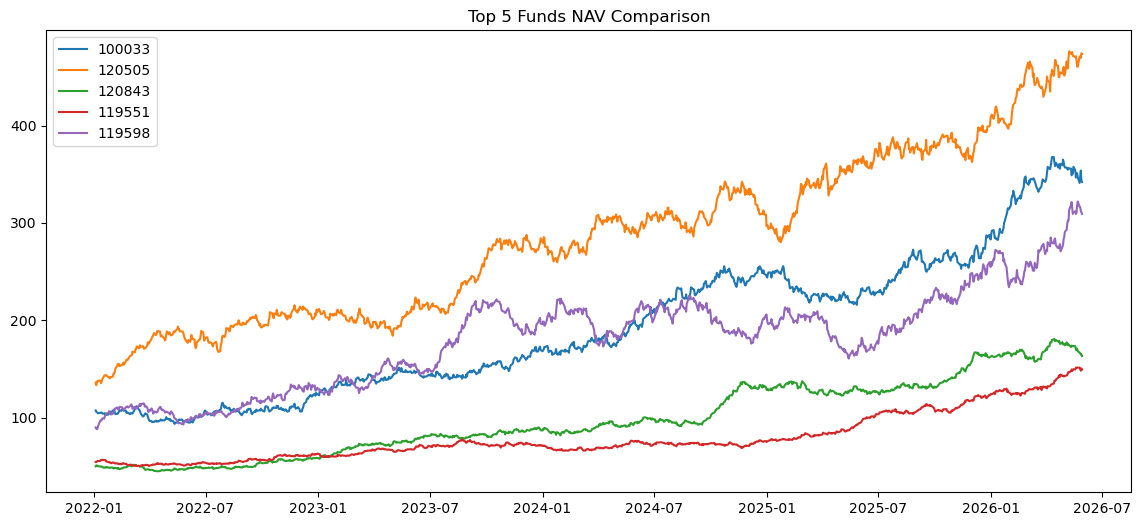

In [63]:
plt.figure(figsize=(14,6))

for code in top5_codes:
    temp = plot_data[
        plot_data["amfi_code"] == code
    ]

    plt.plot(
        temp["date"],
        temp["nav"],
        label=str(code)
    )

plt.legend()

plt.title("Top 5 Funds NAV Comparison")

plt.show()

In [64]:
plt.savefig(
    "../Output/benchmark_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>